# Plot entangled input parallelism score (PS) vs participation ratio (PR)
Plot PS vs PR for entangled whisker inputs $h_{\text{entangler}(\mathbf{X}_i)}$ fed as input to each prediction model realization $i$.

##### Import statements:

In [7]:
import os
import pathlib
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib import colormaps
from analysis_metadata.analysis_metadata import Metadata, increment_dir_name, write_metadata
from ws.functions_geometry import participation_ratio

##### Define inputs, parameters:

In [45]:
# Input file:
input_path = os.path.join('/', 'mnt', 'smb', 'locker', 'issa-locker', 'users', 'Dan', 'code', 'ws', 'results', 'run845', 'tngl_pred.pickle')
input_dir = os.path.split(input_path)[0]

# Output parameters:
save_output = True
base_dir_name = 'delta_ps_v_ps_entangler'

##### Load previously-saved results:

In [3]:
tngl_evo_pred_results = pickle.load(open(input_path, 'rb'))
geo_df = tngl_evo_pred_results['geo_df'] 
loss_df = tngl_evo_pred_results['ae_df']

##### Compute participation ratio for prediction model inputs, i.e., $\text{PR}(h_{\text{entangler}}(\mathbf{X}_i))$:

In [18]:
loss_df_pred = loss_df[
    np.array(loss_df.mdl_type=='prediction') & 
    np.array(loss_df.epoch==0)
]

pr = loss_df_pred.apply(lambda x : participation_ratio(x.inpt_test), axis=1)
loss_df_pred['pr'] = pr

##### Compute parallelism score for prediction model inputs, i.e., $\text{PS}(h_{\text{entangler}}(\mathbf{X}_i))$:

In [19]:
geo_df_pred_inpt = geo_df[np.array(geo_df.mdl_type=='prediction') & 
    np.array(geo_df.layer=='inpt') &
    np.array(geo_df.epoch==0)
    ]

# Take mean PS for each prediction model:
geo_df_pred_mu = geo_df_pred_inpt[['pred_mdl_id', 'dichotomy_idx', 'parallelism']]\
    .groupby(['pred_mdl_id', 'dichotomy_idx']).mean()\
    .groupby('pred_mdl_id').mean().reset_index()

##### Merge parallelism score and participation ratio results, scatter:

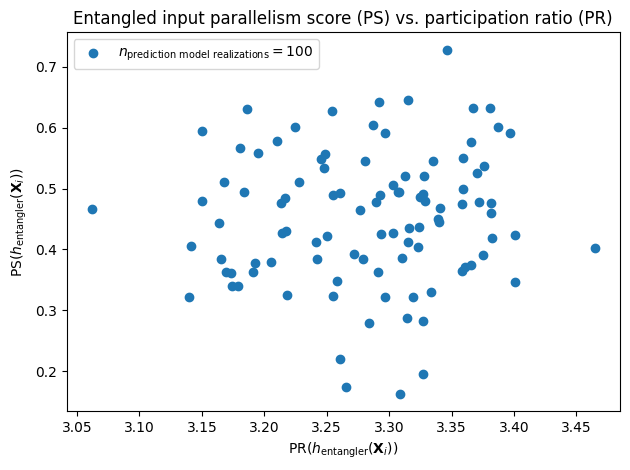

In [50]:
scatter_df = pd.merge(loss_df_pred[['pred_mdl_id', 'pr']], geo_df_pred_mu, on='pred_mdl_id')

# Scatter:
scatter_fig, scatter_ax = plt.subplots()
leg_text = r'$n_{{\text{{prediction model realizations}}}} = {}$'.format(scatter_df.shape[0]) 
plt.scatter(scatter_df.pr, scatter_df.parallelism, label=leg_text)

# Axis labels:
xlabel = r'$\text{PR}(h_{\text{entangler}}(\mathbf{X}_i))$'
ylabel = r'$\text{PS}(h_{\text{entangler}}(\mathbf{X}_i))$'
plt.xlabel(xlabel)
plt.ylabel(ylabel)

# Add title:
title = 'Entangled input parallelism score (PS) vs. participation ratio (PR)'
plt.title(title)

# Add legend:
plt.tight_layout()
plt.legend()

##### Save output:

In [52]:
if save_output:

    # Create output directory:
    input_dir = os.path.split(input_path)[0]
    base_dir_name = 'tngl_inpt_ps_v_pr'
    curr_output_directory = increment_dir_name(input_dir, base_dir_name)
    if not os.path.exists(curr_output_directory):
        pathlib.Path(curr_output_directory).mkdir(parents=True,exist_ok=True)

    # Save figures:
    plt.figure(scatter_fig)
    file_basename = base_dir_name
    ps_png_path = os.path.join(curr_output_directory, file_basename+'.png')
    plt.savefig(ps_png_path)
    ps_svg_path =  os.path.join(curr_output_directory, file_basename+'.svg')
    plt.savefig(ps_svg_path)
    
    # Define metadata:
    M = Metadata()
    M.add_input(input_path)
    M.add_output(ps_png_path)
    M.add_output(ps_svg_path)
    metadata_path = os.path.join(curr_output_directory, file_basename + '.json')
    write_metadata(M, metadata_path)

Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run845/tngl_pred.pickle...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run845/tngl_inpt_ps_v_pr003/tngl_inpt_ps_v_pr.png...
Computing checksum for /mnt/smb/locker/issa-locker/users/Dan/code/ws/results/run845/tngl_inpt_ps_v_pr003/tngl_inpt_ps_v_pr.svg...
